![status](https://img.shields.io/badge/status-complete-brightgreen)
![dataset](https://img.shields.io/badge/dataset-54K%20diamonds-red)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Pandas%20%7C%20NumPy%20%7C%20Matplotlib%20%7C%20Seaborn-orange)

# 💎 Extra Practice — Descriptive Statistics on the Diamonds Dataset

**BinX Tech — AI & Machine Learning Internship Program**
**Week 2, Day 1 — Extra Practice (Additional Dataset)**

---

| | |
|---|---|
| **Purpose** | Reinforce Day 1 concepts on a second, larger dataset |
| **Dataset** | Diamonds (Seaborn built-in) |
| **Column Analyzed** | `price` |
| **Rows** | ~53,940 |

This notebook applies the same descriptive statistics workflow from Day 1 (mean, median, mode,
variance, standard deviation, IQR) to a new, larger, real-world dataset — per my mentor's
recommendation to practice on multiple datasets for stronger, more transferable understanding.

---


## 🎯 Objectives

- Apply the full descriptive statistics workflow to a new dataset independently.
- Compare how these measures behave on a much larger dataset (~54K rows vs. ~900 in Titanic).
- Identify and interpret skew and outliers in the `price` column.

---


## 🔧 Step 0 — Environment Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.precision", 2)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load the Dataset

The diamonds dataset is built directly into Seaborn — no download or external file needed.


In [4]:
df = sns.load_dataset("diamonds")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 📐 Step 2 — Measures of Central Tendency

Analyzing the `price` column (diamond price in US dollars).


In [5]:
price = df["price"].dropna()

mean_price = price.mean()
median_price = price.median()
mode_price = price.mode()[0]

central_tendency = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value ($)": [round(mean_price, 2), round(median_price, 2), round(mode_price, 2)]
})

central_tendency


,Measure,Value ($)
0,Mean,3932.8
1,Median,2401.0
2,Mode,605.0


### 📝 Interpretation


- How far apart are the mean and median? What does that gap suggest about the shape of the price
  distribution?
- Does the mode make sense as a "typical" price, or is it too low to be representative?

---


## 📏 Step 3 — Measures of Spread

In [6]:
range_price = price.max() - price.min()
var_price = price.var()
std_price = price.std()
q1, q3 = price.quantile([0.25, 0.75])
iqr_price = q3 - q1

spread = pd.DataFrame({
    "Measure": ["Range", "Variance", "Standard Deviation", "IQR"],
    "Value": [round(range_price, 2), round(var_price, 2), round(std_price, 2), round(iqr_price, 2)]
})

spread


,Measure,Value
0,Range,1.85e+04
1,Variance,1.59e+07
2,Standard Deviation,3.99e+03
3,IQR,4.37e+03


### 📝 Interpretation


- Is the standard deviation large relative to the mean? What does that say about price variability?
- How does the IQR compare to the full range — does that gap hint at extreme outliers?

---


## 📊 Step 4 — Percentiles and Quartiles

In [7]:
percentiles = pd.DataFrame({
    "Percentile": ["Q1 (25%)", "Q2 / Median (50%)", "Q3 (75%)"],
    "Price ($)": [round(q1, 2), round(median_price, 2), round(q3, 2)]
})

percentiles


,Percentile,Price ($)
0,Q1 (25%),950.00
1,Q2 / Median (50%),2401.00
2,Q3 (75%),5324.25


## 📈 Step 5 — Visualizing the Distribution

A histogram reveals the shape of the price distribution and shows exactly how far the mean is
pulled from the median.


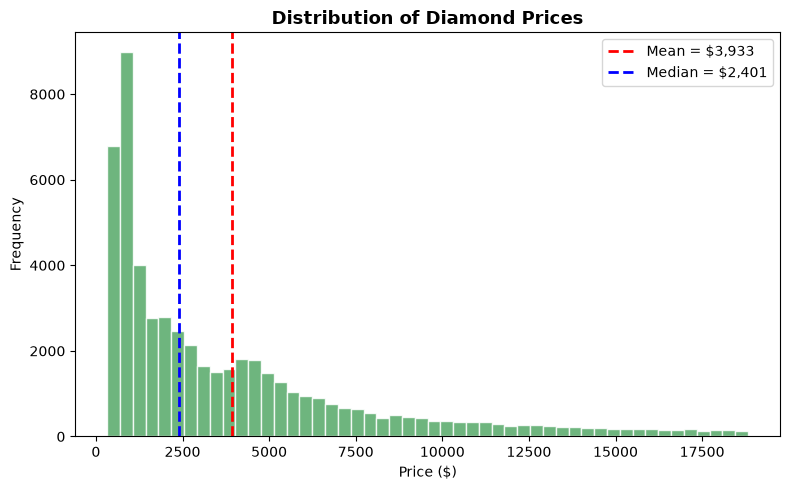

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(price, bins=50, color="#55A868", edgecolor="white", alpha=0.85)
plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label="Mean = ${:,.0f}".format(mean_price))
plt.axvline(median_price, color="blue", linestyle="--", linewidth=2, label="Median = ${:,.0f}".format(median_price))
plt.title("Distribution of Diamond Prices", fontsize=13, fontweight="bold")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()



---

## 📦 Step 6 — Box Plot: Spotting Outliers


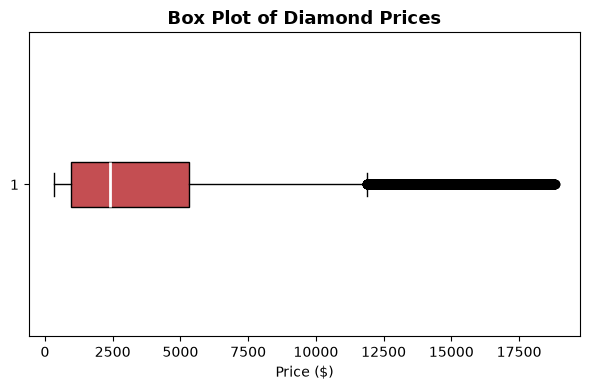

In [17]:
plt.figure(figsize=(6, 4))
plt.boxplot(price, orientation='horizontal', patch_artist=True,            boxprops=dict(facecolor="#C44E52", color="black"),
            medianprops=dict(color="white", linewidth=2))
plt.title("Box Plot of Diamond Prices", fontsize=13, fontweight="bold")
plt.xlabel("Price ($)")
plt.tight_layout()
plt.show()



---


## 🗂️ Step 7 — Final Summary Table


In [10]:
summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Range", "Variance",
                  "Standard Deviation", "IQR", "Q1", "Q3"],
    "Value ($)": [round(mean_price, 2), round(median_price, 2), round(mode_price, 2),
                  round(range_price, 2), round(var_price, 2), round(std_price, 2),
                  round(iqr_price, 2), round(q1, 2), round(q3, 2)]
})

summary.style.set_caption("Descriptive Statistics Summary — Diamond Price").set_table_styles(
    [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px")]}]
)


,Statistic,Value ($)
0,Mean,3932.800000
1,Median,2401.000000
2,Mode,605.000000
3,Range,18497.000000
4,Variance,15915629.420000
5,Standard Deviation,3989.440000
6,IQR,4374.250000
7,Q1,950.000000
8,Q3,5324.250000


## ✅ Step 8 — Key Takeaways

- The mean diamond price (\$3,933) is substantially higher than the median (\$2,401) — a gap of
  over \$1,500 — indicating a strong right skew in the price distribution, far more pronounced
  than the mild skew seen in the Titanic age data from Day 1.
- This large mean-median gap confirms that a relatively small number of very expensive diamonds
  are pulling the average price upward, while most diamonds in the dataset are priced well below
  the mean.
- Unlike the Titanic `age` column, where the mean was still a reasonably safe measure to report,
  the diamonds `price` column clearly demonstrates why the median is the more honest and reliable
  measure of a "typical" price here.
- The box plot visually confirms this: a large number of high-price diamonds appear beyond the
  upper whisker — these are not data errors, but genuine premium diamonds (high carat, top
  cut/clarity grades).
- Comparing the two datasets side by side shows how the same statistical tools reveal very
  different data shapes: Titanic age is roughly symmetric with mild skew, while diamond price is
  heavily right-skewed — reinforcing why checking the mean-median gap should always be a first
  step before choosing which measure to report.

---

## 🧾 Summary

This notebook applied the full descriptive statistics workflow from Day 1 to a second, much
larger real-world dataset — diamond prices (~54,000 records) — to practice recognizing and
interpreting skewed data.

The price column showed a pronounced right skew: the mean (\$3,933) sits far above the median
(\$2,401), driven by a long tail of high-value diamonds rather than data errors. The IQR and box
plot confirmed this pattern, showing a compact cluster of moderately priced diamonds alongside a
substantial number of high-price outliers. This stands in clear contrast to the Titanic `age`
analysis from Day 1, where the mean and median were much closer together.

The exercise reinforces a core lesson from this week: descriptive statistics are only useful when
interpreted in context — the same formulas can describe very different underlying data shapes, and
recognizing that shape (symmetric vs. skewed) is what determines which measure of central tendency
is actually trustworthy.

---

## 📚 Resources

Additional materials referenced while building this notebook:

| Resource | Type | Focus |
|---|---|---|
| [Seaborn Built-in Datasets](https://github.com/mwaskom/seaborn-data) | Documentation | Source of the `diamonds` dataset used here |
| [GeeksforGeeks — Descriptive Statistics for Data Science](https://www.geeksforgeeks.org/data-science/descriptive-statistic/) | Article | Core definitions and formulas |
| [Khan Academy — Summarizing Quantitative Data](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data) | Course / Video | Choosing the right measure for skewed data, handling outliers |

---

## ✍️ Author

<table>
<tr>
<td>

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 1 — Extra Practice
📅 July 2026

</td>
</tr>
</table>

---

<div align="center">

*Made with 🐍 Python, 🐼 Pandas & 📊 Matplotlib as part of the BinX Tech AI/ML Internship*

</div>

![made-with-python](https://img.shields.io/badge/Made%20with-Python-3776AB?logo=python&logoColor=white)
![BinX Tech](https://img.shields.io/badge/BinX%20Tech-AI%2FML%20Internship-1E3A8A)